# Smart Waste Detector with YOLO

## Project Overview

This project trains a YOLO object detection model to identify six categories of waste in images:

- Biodegradable
- Cardboard
- Glass
- Metal
- Paper
- Plastic

The model is trained on the [Garbage Detection - 6 Waste Categories dataset](https://www.kaggle.com/datasets/viswaprakash1990/garbage-detection/data) and executed on Google Colab with GPU acceleration.

The objective is to build a baseline computer vision system that can locate waste objects and classify them in images.

**Note:** The dataset is distributed under the CC BY 4.0 license. Please keep the original attribution when publishing this project.

## 1. Environment Setup

Install the Kaggle command-line interface and the Ultralytics package used to train YOLO.

In [10]:
# Install the libraries required for dataset access and YOLO training.
!pip install -q kaggle ultralytics

## 2. Kaggle Authentication

Create an API token from your Kaggle account settings. The token is entered securely at runtime and is not stored in this notebook.

In [3]:
import os
from getpass import getpass

# Ask for the Kaggle token without displaying or storing it in the notebook.
os.environ["KAGGLE_API_TOKEN"] = getpass(
    "Enter your Kaggle API token: "
)

REDACTED_KAGGLE_TOKEN··········


## 3. Download the Dataset

Download the dataset directly into the temporary Colab runtime.

In [4]:
# Create a temporary working directory in the Colab runtime.
!mkdir -p /content/waste

# Download the dataset from Kaggle.
!kaggle datasets download \
    -d viswaprakash1990/garbage-detection \
    -p /content/waste

Dataset URL: https://www.kaggle.com/datasets/viswaprakash1990/garbage-detection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 191M/191M [00:10<00:00, 19.8MB/s]



## 4. Extract the Dataset

The downloaded archive is extracted so that YOLO can access the image and label folders.

In [5]:
from pathlib import Path
import zipfile

# Locate the downloaded ZIP archive.
zip_files = list(Path("/content/waste").glob("*.zip"))
print(zip_files)

# Extract the archive into the dataset directory.
with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
    zip_ref.extractall("/content/waste/dataset")

[PosixPath('/content/waste/garbage-detection.zip')]


## 5. Inspect the Dataset

Check the extracted files and locate the YAML configuration used by YOLO.

In [ ]:
# Display a sample of the extracted files.
!find /content/waste/dataset -maxdepth 3 -type f | head -30

/content/waste/dataset/GARBAGE CLASSIFICATION/data.yaml


In [7]:
from pathlib import Path

# Search for the YOLO dataset configuration file.
yaml_files = list(Path("/content/waste/dataset").rglob("*.yaml"))
print(yaml_files)

[PosixPath('/content/waste/dataset/GARBAGE CLASSIFICATION/data.yaml')]


In [8]:
from pathlib import Path

# Store the dataset configuration path for training and evaluation.
yaml_files = list(Path("/content/waste/dataset").rglob("*.yaml"))
DATA_YAML = str(yaml_files[0])

print("Dataset configuration:", DATA_YAML)
print(Path(DATA_YAML).read_text())

Configuration utilisée : /content/waste/dataset/GARBAGE CLASSIFICATION/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

roboflow:
  workspace: material-identification
  project: garbage-classification-3
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/material-identification/garbage-classification-3/dataset/2


## 6. Connect Google Drive

Mount Google Drive so that model checkpoints, evaluation plots, and predictions remain available after the Colab runtime ends.

In [11]:
from google.colab import drive

# Mount Google Drive for persistent storage.
drive.mount("/content/drive")

Mounted at /content/drive


## 7. Verify GPU Availability

YOLO training is much faster when Colab provides an NVIDIA GPU.

In [ ]:
# Display the available NVIDIA GPU and driver information.
!nvidia-smi

## 8. Train the YOLO Model

A lightweight YOLO model is fine-tuned for 30 epochs. The best checkpoint is saved to Google Drive.

In [12]:
from ultralytics import YOLO

# Load a lightweight pretrained YOLO model.
model = YOLO("yolo26n.pt")

# Fine-tune the model on the waste detection dataset.
results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    save_period=5,
    patience=10,
    project="/content/drive/MyDrive/smart-waste-detector",
    name="baseline"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/waste/dataset/GARBAGE CLASSIFICATION/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False,

## 9. Evaluate the Best Checkpoint

Evaluate the best model on the test split and generate diagnostic plots such as the confusion matrix.

In [13]:
from pathlib import Path
from ultralytics import YOLO

# Locate the best checkpoint saved by the latest training run.
checkpoint_candidates = sorted(
    Path("/content/drive/MyDrive/smart-waste-detector").glob(
        "baseline*/weights/best.pt"
    )
)
if not checkpoint_candidates:
    raise FileNotFoundError("No best.pt checkpoint was found.")

BEST_MODEL_PATH = str(checkpoint_candidates[-1])
print("Best checkpoint:", BEST_MODEL_PATH)
best_model = YOLO(BEST_MODEL_PATH)

# Evaluate the model on the test set.
test_results = best_model.val(
    data=DATA_YAML,
    split="test",
    plots=True,
    project="/content/drive/MyDrive/smart-waste-detector",
    name="test-evaluation"
)

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 4.3±2.9 MB/s, size: 26.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/waste/dataset/GARBAGE CLASSIFICATION/test/labels... 1042 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1042/1042 435.5it/s 2.4s
val: New cache created: /content/waste/dataset/GARBAGE CLASSIFICATION/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 6.3it/s 10.5s
                   all       1042       3563      0.497      0.406       0.43      0.331
         BIODEGRADABLE          8         49      0.109     0.0625     0.0646     0.0333
             CARDBOARD         11         20   

## 10. Test on New Images

Use the best checkpoint to make predictions on images uploaded from a local computer.

In [19]:
from ultralytics import YOLO

# Reuse the best checkpoint selected during evaluation.
model = YOLO(BEST_MODEL_PATH)

In [18]:
from google.colab import files

# Upload one or more images for inference.
uploaded = files.upload()

Saving WhatsApp Image 2026-08-20 at 00.05.18.jpeg to WhatsApp Image 2026-08-20 at 00.05.18.jpeg
Saving WhatsApp Image 2026-08-20 at 00.05.19 (1).jpeg to WhatsApp Image 2026-08-20 at 00.05.19 (1).jpeg
Saving WhatsApp Image 2026-08-20 at 00.05.19 (2).jpeg to WhatsApp Image 2026-08-20 at 00.05.19 (2).jpeg
Saving WhatsApp Image 2026-08-20 at 00.05.19 (3).jpeg to WhatsApp Image 2026-08-20 at 00.05.19 (3).jpeg
Saving WhatsApp Image 2026-08-20 at 00.05.19.jpeg to WhatsApp Image 2026-08-20 at 00.05.19.jpeg



image 1/1 /content/WhatsApp Image 2026-08-20 at 00.05.18.jpeg: 640x480 1 PAPER, 10.3ms
Speed: 3.6ms preprocess, 10.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/smart-waste-detector/mes-photos-3


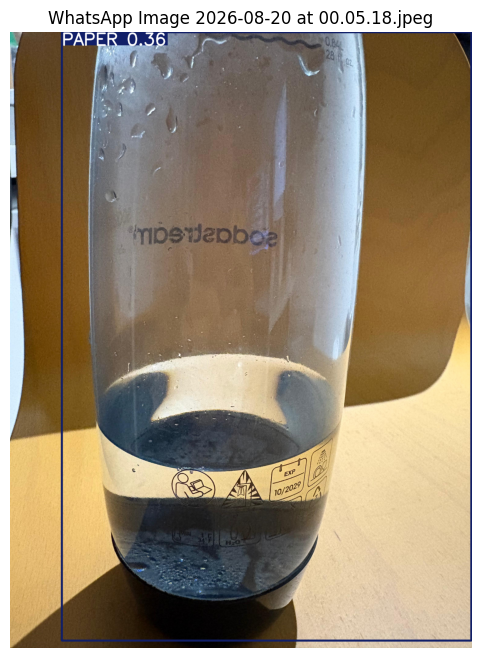


image 1/1 /content/WhatsApp Image 2026-08-20 at 00.05.19 (1).jpeg: 640x480 1 CARDBOARD, 19.0ms
Speed: 4.9ms preprocess, 19.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/smart-waste-detector/mes-photos-4


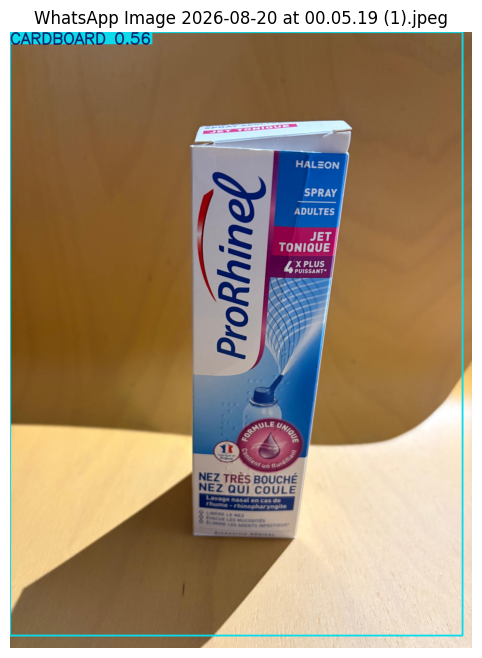


image 1/1 /content/WhatsApp Image 2026-08-20 at 00.05.19 (2).jpeg: 640x480 1 CARDBOARD, 13.5ms
Speed: 4.5ms preprocess, 13.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/smart-waste-detector/mes-photos-5


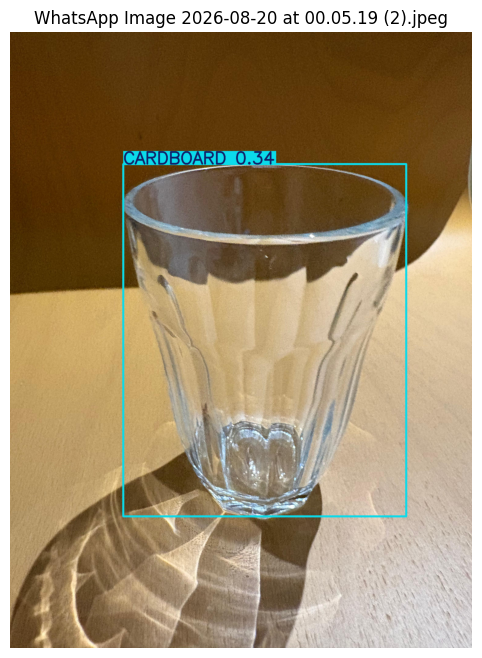


image 1/1 /content/WhatsApp Image 2026-08-20 at 00.05.19 (3).jpeg: 640x480 (no detections), 15.1ms
Speed: 5.2ms preprocess, 15.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/smart-waste-detector/mes-photos-6


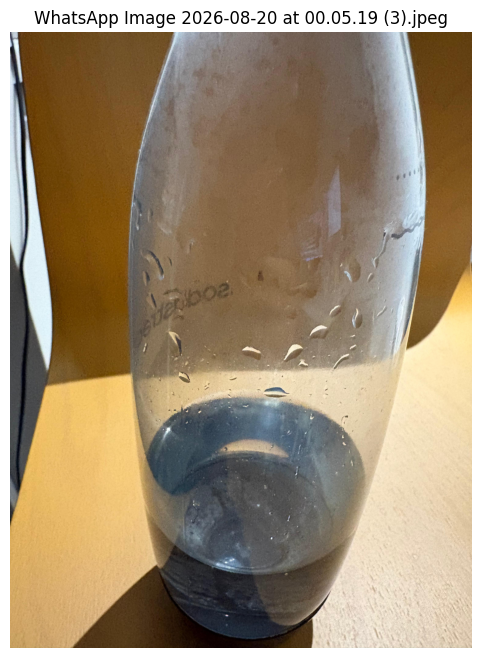


image 1/1 /content/WhatsApp Image 2026-08-20 at 00.05.19.jpeg: 640x480 1 PAPER, 10.8ms
Speed: 3.1ms preprocess, 10.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/smart-waste-detector/mes-photos-7


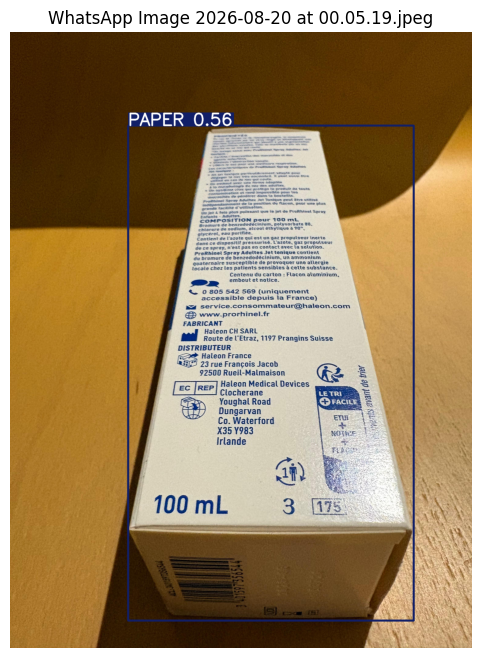

In [20]:
import matplotlib.pyplot as plt

for image_name in uploaded.keys():
    # Run object detection on the uploaded image.
    results = model.predict(
        source=image_name,
        conf=0.25,
        save=True,
        project="/content/drive/MyDrive/smart-waste-detector",
        name="my-photos"
    )

    # Render the predicted bounding boxes and labels.
    annotated_image = results[0].plot()

    # Convert BGR output to RGB for Matplotlib display.
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_image[:, :, ::-1])
    plt.title(image_name)
    plt.axis("off")
    plt.show()

## 11. Baseline Results and Limitations

The baseline model achieved a validation **mAP50 of approximately 0.496** and a **mAP50-95 of approximately 0.344** after 30 epochs.

The model performed better on glass and metal than on paper and plastic. Tests on personal photos also showed confusion between cardboard, paper, glass, and plastic. This suggests a domain gap between the Kaggle images and real-world photos, as well as class imbalance in the validation set.

This project should therefore be presented as a baseline prototype. Future improvements could include collecting more representative images, balancing the classes, adding real-world examples, and retraining the model with stronger augmentation.